# Hybrid Explanation Notebook  

This notebook performs four main functions:

## 1. Load the ML Classification Pipeline
It imports a trained traditional ML model and its TF-IDF vectorizer from the thesis directory.  
These components produce the baseline prediction for each email and serve as the "ground truth"
explanation source using established XAI methods.

## 2. Generate Technical Explanations Using LIME
The Local Interpretable Model-Agnostic Explanations (LIME) method is applied to each email
to highlight which textual features most influenced the ML model's classification decision.
LIME provides granular, human-inspectable reasoning that anchors the rest of this notebook.

## 3. Produce Natural-Language Explanations via Multiple LLMs
A unified prompt is used to query several LLMs (all accessed through a single OpenRouter API
client). Each model transforms the LIME technical output into a clear, public-facing explanation.
This creates a controlled environment for comparing stylistic and communicative differences
across LLMs.

## 4. Evaluate Explanation Readability
Each explanation—whether from the ML-based humanization step or from an LLM—is automatically
assessed using a readability metric. This allows examination of how accessible and
user-friendly the generated explanations are across different model families.

## 5. How Readability Is Calculated in This Notebook
Readability scoring is handled by the `readability_score()` helper function:
- If the `textstat` library is installed, the notebook uses the **Flesch Reading Ease** score  
  (0–100 scale where higher = easier to understand).
- If `textstat` is unavailable, a custom fallback metric is used.  
  This heuristic evaluates average sentence length and the proportion of short words to estimate  
  readability. Shorter sentences and more short words increase the score.

These readability values are stored for each provider and visualized in the summary table  
and the final bar chart, enabling comparison of explanation clarity across model families.

---

## 📁 Dataset
- **Source**: `test_dataset.csv` (converted from `test-00000-of-00001-8a6d39996ec0fb5b.parquet`)
- **Columns**: 
  - `email_text`: Email content (renamed from text_combined)
  - `label`: Binary classification (0 = Safe, 1 = Phishing)
- **Sampling**: 5 random emails selected for detailed analysis (balanced mix when possible)

In [1]:
# Imports & environment
import os
import re
import joblib
import time
from dotenv import load_dotenv
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display  # Add for display()

# LIME
from lime.lime_text import LimeTextExplainer

# OpenAI/OpenRouter
from openai import OpenAI as OR_OpenAI

# typing
from typing import Tuple

# Read project root
try:
    CURRENT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    CURRENT_DIR = os.getcwd()

PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))

# Load .env from project root
env_path = os.path.join(PROJECT_ROOT, ".env")
if os.path.exists(env_path):
    load_dotenv(dotenv_path=env_path)
else:
    print(f"⚠️ .env not found at {env_path} — OpenRouter key may be missing")

print("✅ Project root:", PROJECT_ROOT)

✅ Project root: C:\Users\azizf\Desktop\Hybrid_Model


In [2]:
# Load ML model + TF-IDF vectorizer
ML_DIR = os.path.join(PROJECT_ROOT, "ML pipeline")   # folder with space
MODEL_PATH = os.path.join(ML_DIR, "model.pkl")
VECT_PATH = os.path.join(ML_DIR, "tfidf_vectorizer.pkl")

if not os.path.exists(MODEL_PATH) or not os.path.exists(VECT_PATH):
    raise FileNotFoundError(
        f"Model or vectorizer not found. Expected:\n - {MODEL_PATH}\n - {VECT_PATH}"
    )

print("Loading ML model and TF-IDF...")
ml_model = joblib.load(MODEL_PATH)
tfidf = joblib.load(VECT_PATH)
print(f"Loaded ML model: {type(ml_model).__name__}, vectorizer: {type(tfidf).__name__}")

# Helper: produce probabilities Nx2 [legit_prob, phish_prob]
def model_proba_for_texts(model, vectorizer, texts):
    X = vectorizer.transform(texts)
    # prefer predict_proba
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
        # If two-class, ensure shape Nx2
        if probs.shape[1] >= 2:
            # If columns correspond to classes [0,1], return as-is
            return probs[:, :2]
    # fallback to decision_function
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        if scores.ndim == 1:
            # convert via sigmoid
            ph = 1.0 / (1.0 + np.exp(-scores))
            return np.vstack([1-ph, ph]).T
        else:
            exp_scores = np.exp(scores)
            probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
            return probs[:, :2]
    # last resort uniform
    n = len(texts)
    return np.tile(np.array([0.5, 0.5]), (n, 1))

Loading ML model and TF-IDF...
Loaded ML model: CalibratedClassifierCV, vectorizer: TfidfVectorizer


In [3]:
# Load test_dataset.csv
TEST_DATASET_PATH = os.path.join("test_dataset.csv")
if not os.path.exists(TEST_DATASET_PATH):
    raise FileNotFoundError(f"test_dataset.csv not found at {TEST_DATASET_PATH}")

print("Loading dataset:", TEST_DATASET_PATH)
df = pd.read_csv(TEST_DATASET_PATH)

# Rename text_combined to email_text
df.rename(columns={'text_combined': 'email_text'}, inplace=True)

print(f"✅ Loaded dataset: {len(df)} emails (phish={(df['label']==1).sum()}, legit={(df['label']==0).sum()})")

# Select 5 random emails
np.random.seed(42) 

# Try to get a balanced mix
phishing_count = (df['label']==1).sum()
safe_count = (df['label']==0).sum()

if phishing_count >= 3 and safe_count >= 2:
    # Get 3 phishing and 2 safe
    ph = df[df['label']==1].sample(n=3, random_state=42)
    lg = df[df['label']==0].sample(n=2, random_state=42)
    sample_df = pd.concat([ph, lg]).sample(frac=1, random_state=42).reset_index(drop=True)
elif phishing_count >= 2 and safe_count >= 3:
    # Get 2 phishing and 3 safe
    ph = df[df['label']==1].sample(n=2, random_state=42)
    lg = df[df['label']==0].sample(n=3, random_state=42)
    sample_df = pd.concat([ph, lg]).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    # Just get 5 random emails regardless of class
    sample_df = df.sample(n=min(5, len(df)), random_state=42).reset_index(drop=True)

print(f"\n📧 Selected {len(sample_df)} random emails for analysis:")
print(f"   Phishing: {(sample_df['label']==1).sum()}")
print(f"   Safe: {(sample_df['label']==0).sum()}")
print()

for i, r in sample_df.iterrows():
    label_str = 'Phishing' if r['label']==1 else 'Safe'
    preview = r['email_text'][:120].replace('\n', ' ')
    print(f"  [{i+1}] {label_str:8s} | {preview}...")

Loading dataset: test_dataset.csv
✅ Loaded dataset: 16498 emails (phish=8595, legit=7903)

📧 Selected 5 random emails for analysis:
   Phishing: 3
   Safe: 2

  [1] Phishing | daily top 10 inamatna_1994hitechcc daily top 10 cnncom top videos stories aug 1 2008 358 pm edt top 10 videos 1 paris hi...
  [2] Safe     | rohit khare rr gawxdqugmailcom hey rare id crosspost ip fascinating hope dont settlenseal id like learn think public int...
  [3] Phishing | looking good match take tonight youve fou nd place decant absentminded need someone special take evening youve fou nd pl...
  [4] Phishing | iq standard life insurance sliinsurancemailnet multipart message mime format _nextpart_000_68d343_01c210a5ce2c4050 conte...
  [5] Safe     | heartland industrial partners received response yet dave delainey feb 21 memo forwarded additional information investmen...


In [4]:
print("Running ML predictions (sample) and generating LIME explanations...")

probs = model_proba_for_texts(ml_model, tfidf, sample_df['email_text'].tolist())
sample_df['ml_prob'] = probs[:,1]
sample_df['ml_pred'] = (probs[:,1] >= 0.5).astype(int)

for i,row in sample_df.iterrows():
    print(f" Email {i+1}: ML_pred={'Phish' if row['ml_pred']==1 else 'Legit'} (p={row['ml_prob']:.1%}) True={row['label']}")

explainer = LimeTextExplainer(class_names=["Legit","Phishing"])
lime_explanations = []
for i,row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="LIME"):
    txt = row['email_text']
    exp = explainer.explain_instance(txt, lambda texts: model_proba_for_texts(ml_model, tfidf, texts), num_features=10, num_samples=500)
    formatted = []
    for token, weight in exp.as_list():
        side = "Phishing" if weight > 0 else "Legit"
        formatted.append(f"{token:30s} {weight:+.4f} -> {side}")
    lime_text = "\n".join(formatted)
    lime_explanations.append({'as_list': exp.as_list(), 'formatted': lime_text})
    print(f"\n--- Email {i+1} LIME ---\n{lime_text}\n")

sample_df['lime_explanation'] = lime_explanations
print("✅ LIME explanations ready.")

Running ML predictions (sample) and generating LIME explanations...
 Email 1: ML_pred=Legit (p=48.4%) True=1
 Email 2: ML_pred=Legit (p=9.8%) True=0
 Email 3: ML_pred=Phish (p=99.2%) True=1
 Email 4: ML_pred=Phish (p=99.9%) True=1
 Email 5: ML_pred=Legit (p=0.3%) True=0


LIME:  20%|██        | 1/5 [00:00<00:00,  4.37it/s]


--- Email 1 LIME ---
news                           -0.1951 -> Legit
cable                          +0.1330 -> Phishing
daily                          -0.1303 -> Legit
mark                           -0.1101 -> Legit
aug                            -0.1067 -> Legit
videos                         +0.0814 -> Phishing
n                              +0.0682 -> Phishing
love                           +0.0680 -> Phishing
sex                            +0.0626 -> Phishing
go                             +0.0573 -> Phishing



LIME:  60%|██████    | 3/5 [00:00<00:00,  4.54it/s]


--- Email 2 LIME ---
employees                      -0.1467 -> Legit
guy                            -0.1138 -> Legit
forwarded                      -0.1092 -> Legit
2004                           +0.0916 -> Phishing
2002                           -0.0732 -> Legit
chance                         +0.0554 -> Phishing
employee                       -0.0545 -> Legit
never                          +0.0416 -> Phishing
older                          +0.0208 -> Phishing
5                              -0.0010 -> Legit


--- Email 3 LIME ---
te                             +0.0350 -> Phishing
u                              +0.0339 -> Phishing
py                             -0.0246 -> Legit
want                           +0.0225 -> Phishing
turn                           +0.0160 -> Phishing
nd                             +0.0157 -> Phishing
ur                             +0.0118 -> Phishing
address                        -0.0111 -> Legit
good                           +0.0103 -> Phishing
browser   

LIME:  80%|████████  | 4/5 [00:00<00:00,  4.80it/s]


--- Email 4 LIME ---
20                             +0.0110 -> Phishing
life                           +0.0109 -> Phishing
phone                          +0.0086 -> Phishing
us                             +0.0084 -> Phishing
email                          +0.0064 -> Phishing
2002                           -0.0039 -> Legit
instead                        -0.0020 -> Legit
increases                      -0.0016 -> Legit
15                             -0.0012 -> Legit
state                          -0.0008 -> Legit



LIME: 100%|██████████| 5/5 [00:01<00:00,  3.41it/s]


--- Email 5 LIME ---
enron                          -0.0918 -> Legit
2001                           -0.0597 -> Legit
thanks                         -0.0255 -> Legit
role                           -0.0208 -> Legit
view                           -0.0071 -> Legit
9                              -0.0063 -> Legit
typical                        -0.0052 -> Legit
short                          -0.0044 -> Legit
want                           -0.0004 -> Legit
expand                         -0.0001 -> Legit

✅ LIME explanations ready.


In [5]:
# OpenRouter client (single API key to call multiple models)
OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")
if not OPENROUTER_KEY:
    print("⚠️ OPENROUTER_API_KEY not found in .env. LLM calls will fail.")
    openrouter_client = None
else:
    try:
        openrouter_client = OR_OpenAI(api_key=OPENROUTER_KEY, base_url="https://openrouter.ai/api/v1")
        print("✅ OpenRouter client configured.")
    except Exception as e:
        openrouter_client = None
        print("⚠️ Failed to create OpenRouter client:", e)


MODEL_IDS = {
    "DeepSeek": "deepseek/deepseek-chat-v3.1",     
    "GPT": "openai/gpt-4.1",                       
    "Claude": "anthropic/claude-3.5-sonnet",            
}

# Thin wrapper — single function to call OpenRouter with chosen model name
def call_openrouter_model(prompt: str, model_id: str, temperature: float = 0.3, timeout: int = 30) -> Tuple[str, str]:
    """
    Calls OpenRouter chat completions using provided model_id.
    Returns (text, status) where status is "ok" or "error".
    """
    if openrouter_client is None:
        return ("❌ OpenRouter client not configured.", "error")
    try:
        resp = openrouter_client.chat.completions.create(
            model=model_id,
            messages=[{"role":"user","content":prompt}],
            temperature=temperature,
            max_tokens=800,
        )
        txt = resp.choices[0].message.content.strip()
        return (txt, "ok")
    except Exception as e:
        return (f"❌ OpenRouter request failed: {e}", "error")

✅ OpenRouter client configured.


In [6]:
# Unified prompt template used for all LLMs
LLM_PROMPT_TEMPLATE = """You are a professional phishing detector and cybersecurity expert.
Explain the following LIME-based technical analysis to a member of the public with ZERO technical knowledge.
Be clear, concise, and friendly.

Tasks:
1) Say why the email was flagged (or not) using the LIME top indicators.
2) Explain top 3 suspicious or safe signals in plain language (no jargon).
3) Provide simple actionable advice (what to do next).

Write in three short paragraphs. Keep it direct and easy to understand.
--- EMAIL PREVIEW ---
{email_preview}
--- LIME TECHNICAL OUTPUT ---
{lime_text}
--- END ---
"""

# Readability scoring helper
def readability_score(text: str) -> float:
    """
    Return a higher-is-easier readability score.
    Prefers textstat.flesch_reading_ease if available, otherwise fallback heuristic.
    """
    try:
        import textstat
        score = textstat.flesch_reading_ease(text)
        # Normalize to a positive scale; Flesch typically 0-100 (higher easier)
        return float(score)
    except Exception:
        # fallback heuristic: shorter sentences and shorter words => easier
        sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
        words = re.findall(r'\w+', text)
        if not words or not sentences:
            return 0.0
        avg_sent = len(words) / len(sentences)
        short_words_pct = sum(1 for w in words if len(w)<=4) / len(words)
        # Compose heuristic: higher is easier
        heuristic = max(0.0, 120 - (avg_sent * 4) + (short_words_pct * 20))
        return float(heuristic)

In [7]:
print("\n" + "="*60)
print("GENERATING LLM EXPLANATIONS")
print("="*60)

providers = list(MODEL_IDS.keys())

# Timing storage for LLM explanations
llm_expl_time_total = {prov: 0.0 for prov in providers}
llm_expl_call_count = {prov: 0 for prov in providers}


# Prepare storage columns
for prov in providers:
    sample_df[f'llm_{prov}_explanation'] = None
    sample_df[f'llm_{prov}_status'] = None
    sample_df[f'llm_{prov}_readability'] = None

# Iterate each email and call each provider
total_calls = len(sample_df) * len(providers)
print(f"\nProcessing {len(sample_df)} emails × {len(providers)} providers = {total_calls} total calls\n")

for i, row in sample_df.iterrows():
    email_preview = row['email_text'][:600].replace('\n', ' ')
    lime_text = row['lime_explanation']['formatted']
    prompt = LLM_PROMPT_TEMPLATE.format(email_preview=email_preview, lime_text=lime_text)
    
    print(f"\n{'='*80}")
    print(f"📧 EMAIL {i+1}")
    print(f"{'='*80}")
    print(f"Preview: {row['email_text'][:150]}...")
    print(f"True Label: {'Phishing' if row['label']==1 else 'Safe'}")
    print(f"ML Prediction: {'Phishing' if row['ml_pred']==1 else 'Safe'} (confidence: {row['ml_prob']:.1%})")
    print(f"{'-'*80}\n")
    
    for prov in providers:
        model_id = MODEL_IDS[prov]
        start_llm = time.perf_counter()

        txt, status = call_openrouter_model(prompt, model_id)
        
        elapsed = time.perf_counter() - start_llm
        llm_expl_time_total[prov] += elapsed
        llm_expl_call_count[prov] += 1

        score = readability_score(txt) if status == "ok" else None
        
        sample_df.at[i, f'llm_{prov}_explanation'] = txt
        sample_df.at[i, f'llm_{prov}_status'] = status
        sample_df.at[i, f'llm_{prov}_readability'] = score
        
        # Print full explanation with formatting
        print(f"🤖 {prov.upper()}")
        print(f"   Status: {status}")
        print(f"   Readability Score: {score:.2f}" if score else "   Readability Score: N/A")
        print(f"\n{txt}\n")
        print(f"{'-'*80}\n")
        
        time.sleep(0.5)  # Rate limiting

print("\n" + "="*60)
print("✅ LLM EXPLANATION GENERATION COMPLETE")
print("="*60)


GENERATING LLM EXPLANATIONS

Processing 5 emails × 3 providers = 15 total calls


📧 EMAIL 1
Preview: daily top 10 inamatna_1994hitechcc daily top 10 cnncom top videos stories aug 1 2008 358 pm edt top 10 videos 1 paris hilton takes mccain httpwwwcnnco...
True Label: Phishing
ML Prediction: Safe (confidence: 48.4%)
--------------------------------------------------------------------------------

🤖 DEEPSEEK
   Status: ok
   Readability Score: 75.90

This email was flagged as a potential phishing attempt because several words in it are commonly used in scam messages to trick people. Our analysis shows that words like "cable," "videos," and "love" made the email look suspicious, while words like "news" and "daily" made it seem more legitimate. However, the suspicious signals were stronger overall.

Here are the top reasons it was considered suspicious:
1.  **"Cable":** Scammers often use this word in fake billing or service cancellation threats.
2.  **"Videos":** This is a common trick to

In [8]:
print("\n" + "="*60)
print("⏱️ LLM EXPLANATION GENERATION TIME (HYBRID ML + LLM)")
print("="*60)

timing_rows = []

for prov in providers:
    total_time = llm_expl_time_total[prov]
    calls = llm_expl_call_count[prov]

    if calls == 0:
        continue

    avg_time = total_time / calls

    timing_rows.append({
        "Provider": prov,
        "Total Time (sec)": total_time,
        "Calls": calls,
        "Avg Time per Explanation (sec)": avg_time,
        "Avg Time per Explanation (ms)": avg_time * 1000
    })

    print(f"\n{prov}")
    print(f"   Total explanation time: {total_time:.2f} sec")
    print(f"   Explanations generated: {calls}")
    print(f"   Avg per explanation:    {avg_time:.2f} sec ({avg_time*1000:.0f} ms)")

timing_df = pd.DataFrame(timing_rows)
display(timing_df)


⏱️ LLM EXPLANATION GENERATION TIME (HYBRID ML + LLM)

DeepSeek
   Total explanation time: 33.62 sec
   Explanations generated: 5
   Avg per explanation:    6.72 sec (6725 ms)

GPT
   Total explanation time: 20.73 sec
   Explanations generated: 5
   Avg per explanation:    4.15 sec (4146 ms)

Claude
   Total explanation time: 35.22 sec
   Explanations generated: 5
   Avg per explanation:    7.04 sec (7045 ms)


,Provider,Total Time (sec),Calls,Avg Time per Explanation (sec),Avg Time per Explanation (ms)
0,DeepSeek,33.624453,5,6.724891,6724.89068
1,GPT,20.730212,5,4.146042,4146.04240
2,Claude,35.223042,5,7.044608,7044.60844


In [9]:
print("Humanizing ML (LIME) outputs...")

def humanize_lime(lime_entry):
    items = lime_entry['as_list'][:6]
    pos = [w for w, wt in items if wt > 0]
    neg = [w for w, wt in items if wt <= 0]
    parts = []
    if pos:
        parts.append("The model flagged these suspicious indicators: " + ", ".join(pos) + ".")
    if neg:
        parts.append("These terms suggested the message is likely safe: " + ", ".join(neg) + ".")
    parts.append("Advice: Do not click unexpected links; verify sender by contacting the service directly.")
    return " ".join(parts)

sample_df['ml_explanation_text'] = sample_df['lime_explanation'].apply(humanize_lime)

# Build results table without ML readability
results = []
for i,row in sample_df.iterrows():
    r = {
        "email_index": i+1,
        "true_label": "Phish" if row['label']==1 else "Legit",
        "ml_pred": "Phish" if row['ml_pred']==1 else "Legit",
        "ml_prob": float(row['ml_prob']),
    }
    for prov in providers:
        r[f"{prov}_status"] = row.get(f'llm_{prov}_status')
        r[f"{prov}_readability"] = row.get(f'llm_{prov}_readability')
    results.append(r)

results_df = pd.DataFrame(results)
results_df

Humanizing ML (LIME) outputs...


,email_index,true_label,ml_pred,ml_prob,DeepSeek_status,DeepSeek_readability,GPT_status,GPT_readability,Claude_status,Claude_readability
0,1,Phish,Legit,0.483631,ok,75.904762,ok,67.780433,ok,54.450000
1,2,Legit,Legit,0.097816,ok,64.247576,ok,70.252632,ok,21.517382
2,3,Phish,Phish,0.992416,ok,57.818182,ok,34.340206,ok,36.227194
3,4,Phish,Phish,0.999383,ok,59.904360,ok,64.861350,ok,40.571429
4,5,Legit,Legit,0.003104,ok,70.078512,ok,76.272727,ok,7.873684


Aggregating readability scores and showing comparison...

📊 Readability Summary by Provider:


,Provider,Mean Readability,Std Dev,Count
0,DeepSeek,65.590679,6.649373,5
1,GPT,62.701470,14.669842,5
2,Claude,32.127938,16.045084,5



✅ Saved: C:\Users\azizf\Desktop\Hybrid_Model\pictures\llm_readability_comparison.png


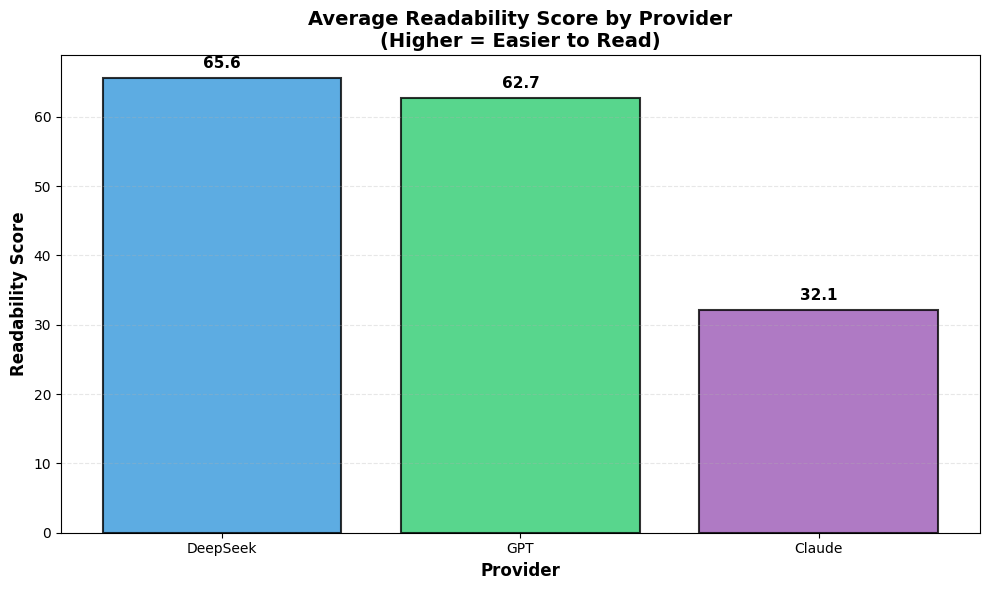


🏆 Top provider by readability: DeepSeek
   Mean score: 65.59
   Std dev: 6.65
   Sample size: 5


In [10]:
print("Aggregating readability scores and showing comparison...\n")

# Compute mean readability per provider
summary = []

for prov in providers:
    col = f"{prov}_readability"
    scores = results_df[col].dropna().astype(float).values if col in results_df.columns else np.array([])
    summary.append({
        "Provider": prov,
        "Mean Readability": float(np.mean(scores)) if len(scores) > 0 else np.nan,
        "Std Dev": float(np.std(scores)) if len(scores) > 0 else np.nan,
        "Count": len(scores)
    })

summary_df = pd.DataFrame(summary).sort_values(by="Mean Readability", ascending=False).reset_index(drop=True)

print("📊 Readability Summary by Provider:")
print("="*60)
display(summary_df)
print("="*60)

# Plot
fig = plt.figure(figsize=(10, 6))
valid_data = summary_df[summary_df['Mean Readability'].notna()]

if len(valid_data) > 0:
    
    colors = ['#3498db', '#2ecc71', '#9b59b6']  # Blue, Green, Purple
    
    bars = plt.bar(valid_data['Provider'], valid_data['Mean Readability'], 
                   color=colors[:len(valid_data)], alpha=0.8, 
                   edgecolor='black', linewidth=1.5)
    
    plt.title("Average Readability Score by Provider\n(Higher = Easier to Read)", 
              fontsize=14, fontweight='bold')
    plt.ylabel("Readability Score", fontsize=12, fontweight='bold')
    plt.xlabel("Provider", fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(valid_data.iterrows()):
        plt.text(i, row['Mean Readability'] + 1, f"{row['Mean Readability']:.1f}", 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    
    # Save to pictures folder
    pictures_dir = os.path.join(PROJECT_ROOT, "pictures")
    os.makedirs(pictures_dir, exist_ok=True)
    output_path = os.path.join(pictures_dir, "llm_readability_comparison.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✅ Saved: {output_path}")
    
    plt.show()
    
    # Print top provider
    top = valid_data.iloc[0]
    print(f"\n🏆 Top provider by readability: {top['Provider']}")
    print(f"   Mean score: {top['Mean Readability']:.2f}")
    print(f"   Std dev: {top['Std Dev']:.2f}")
    print(f"   Sample size: {int(top['Count'])}")
else:
    print("\n⚠️ No readability scores available")
    print("   Likely causes: OpenRouter key not configured or API errors")